# CatBoostRegressor for log(attendance)
CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=200), fit and done.

Features: table_rank, opponent_table_rank, days_since_last_home_game, day_of_week, year,
venue_name, home_team, away_team, stadium_capacity, metro_size,
dedicated_soccer_facility, shared_with_other_league. Missing numeric features (stadium_capacity/
metro_size on old/renamed venues we never built isochrones for) are left
as NaN -> CatBoost handles this

random train_test_split overstates how well this generalizes, because
most of these features (venue_name, home_team, stadium_capacity, metro_size) are
constant within a team across its games, so it just learns to identify teams. 
Leave-One-Team-Out: hold out every game for one team at a time, 
train on every other team, and see if the model can predict a team it has
never seen. 

Applies the trained model to the Queens counterfactual: a synthetic Gotham FC home
schedule with Etihad Park's real venue features instead of Red Bull Arena's.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split

from plot_theme import set_mpl_theme
set_mpl_theme()

np.random.seed(42)

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAT_FEATURES = ["day_of_week", "venue_name", "home_team", "away_team"]
NUM_FEATURES = ["table_rank", "opponent_table_rank", "days_since_last_home_game", "year",
                 "stadium_capacity", "metro_size",
                 "dedicated_soccer_facility", "shared_with_other_league",
                 "team_venue_tenure", "team_league_tenure"]
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = "log_attendance"

df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "catboost_training_table.csv"), parse_dates=["date_time_utc"])
for c in CAT_FEATURES:
    df[c] = df[c].astype(str)
df = df.sort_values("date_time_utc").reset_index(drop=True)
print(f"Loaded {len(df)} rows, {df['home_team'].nunique()} teams, seasons {sorted(df['year'].unique())}")

X = df[FEATURES]
y = df[TARGET]

Loaded 1132 rows, 14 teams, seasons [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


Normal 80/20 Train Test Split
0:	learn: 0.6057910	test: 0.6436918	best: 0.6436918 (0)	total: 62ms	remaining: 1m 1s


200:	learn: 0.1884479	test: 0.3443876	best: 0.3443876 (200)	total: 425ms	remaining: 1.69s


400:	learn: 0.1346584	test: 0.3472588	best: 0.3440880 (234)	total: 792ms	remaining: 1.18s


600:	learn: 0.1013001	test: 0.3490205	best: 0.3440880 (234)	total: 1.16s	remaining: 767ms


800:	learn: 0.0774203	test: 0.3503096	best: 0.3440880 (234)	total: 1.49s	remaining: 371ms


999:	learn: 0.0606647	test: 0.3517293	best: 0.3440880 (234)	total: 1.86s	remaining: 0us

bestTest = 0.3440880063
bestIteration = 234

Shrink model to first 235 iterations.
Random split Pearson r: 0.867


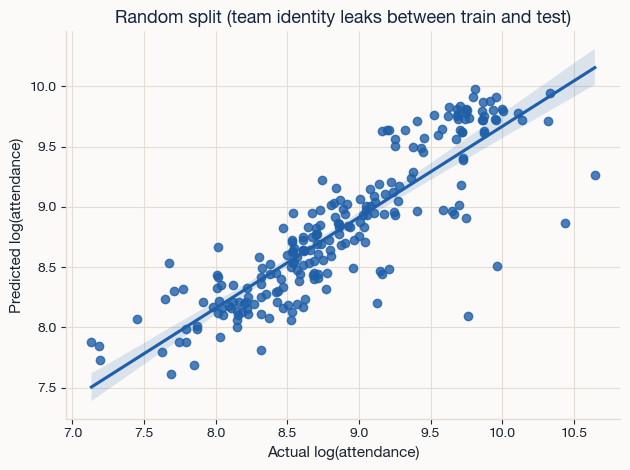

In [2]:
print("Normal 80/20 Train Test Split")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=200)
catboost_model.fit(X_train, y_train, cat_features=CAT_FEATURES, eval_set=(X_test, y_test))
y_pred = catboost_model.predict(X_test)
corr, p_value = pearsonr(y_test.squeeze(), y_pred.squeeze())
print(f"Random split Pearson r: {corr:.3f}")

sns.regplot(x=y_test, y=y_pred)
plt.xlabel("Actual log(attendance)")
plt.ylabel("Predicted log(attendance)")
plt.title("Random split (team identity leaks between train and test)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "catboost_random_split_fit.png"), dpi=150)
plt.show()

Leave-One-Team-Out CV


         held_out_team  n_games  pearson_r
     Washington Spirit      102   0.878067
       NJ/NY Gotham FC      107   0.792924
      Seattle Reign FC      107   0.679803
     San Diego Wave FC       59   0.616756
         Orlando Pride      108   0.463375
          Houston Dash      107   0.332322
    Portland Thorns FC      111   0.329338
North Carolina Courage      103   0.328114
         Angel City FC       41   0.249246
                Bay FC       33   0.235457
  Racing Louisville FC       62   0.229777
      Chicago Stars FC      103   0.215981
        Utah Royals FC       59   0.001033
   Kansas City Current       30  -0.110579

Pooled LOTO Pearson r (primary headline number): 0.496 (p=2.4e-71)


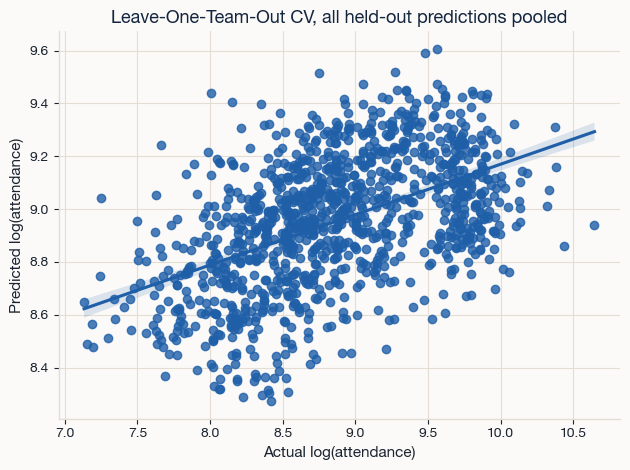

In [3]:
print("Leave-One-Team-Out CV")
# For each team, train on every other team's games, test on that team's games
loto_true, loto_pred, loto_rows = [], [], []
for team in df["home_team"].unique():
    test = df[df["home_team"] == team]
    train = df[df["home_team"] != team]
    X_train, y_train = train[FEATURES], train[TARGET]
    X_test, y_test = test[FEATURES], test[TARGET]

    model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=False)
    model.fit(X_train, y_train, cat_features=CAT_FEATURES)
    y_pred = model.predict(X_test)

    corr, _ = pearsonr(y_test, y_pred)
    loto_rows.append({"held_out_team": team, "n_games": len(test), "pearson_r": corr})
    loto_true.extend(y_test.tolist())
    loto_pred.extend(y_pred.tolist())

loto_df = pd.DataFrame(loto_rows).sort_values("pearson_r", ascending=False)
loto_df.to_csv(os.path.join(OUTPUT_DIR, "catboost_loto_cv_results.csv"), index=False)
print(loto_df.to_string(index=False))

pooled_corr, pooled_p = pearsonr(loto_true, loto_pred)
print(f"\nPooled LOTO Pearson r (primary headline number): {pooled_corr:.3f} (p={pooled_p:.3g})")
pd.DataFrame([{"pooled_pearson_r": pooled_corr, "pooled_p_value": pooled_p}]).to_csv(
    os.path.join(OUTPUT_DIR, "catboost_loto_pooled_summary.csv"), index=False)

sns.regplot(x=np.array(loto_true), y=np.array(loto_pred))
plt.xlabel("Actual log(attendance)")
plt.ylabel("Predicted log(attendance)")
plt.title("Leave-One-Team-Out CV, all held-out predictions pooled")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "catboost_loto_fit.png"), dpi=150)
plt.show()

In [4]:
print("Final model: fit on all data, for SHAP + Queens scenario")
final_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=200)
final_model.fit(X, y, cat_features=CAT_FEATURES)
final_model.save_model(os.path.join(OUTPUT_DIR, "catboost_attendance_model.cbm"))
print(f"Final model saved to {os.path.join(OUTPUT_DIR, 'catboost_attendance_model.cbm')}")

print("\nFeature importance (PredictionValuesChange):")
imp = pd.Series(final_model.get_feature_importance(), index=FEATURES).sort_values(ascending=False)
print(imp)
imp.to_csv(os.path.join(OUTPUT_DIR, "catboost_feature_importance.csv"))


# Queens counterfactual: synthetic Gotham FC home schedule at Etihad Park instead of Red Bull
# Arena, using this run's freshly-trained final_model/df.
print("\n\n=== Queens counterfactual ===")

# Etihad Park's real venue features. metro_size read from 11's own catchment-population output
# (r5py isochrone, computed for ETIHAD_PARK there but dropped before venue_features since Etihad
# isn't in stadium_accessibility.csv) instead of hardcoded.
catchment_pop = pd.read_csv(os.path.join(OUTPUT_DIR, "venue_catchment_population.csv")).set_index("stadium_id")
ETIHAD_METRO_SIZE = int(catchment_pop.loc["ETIHAD_PARK", "catchment_pop_60min"])
ETIHAD_CAPACITY = 25000
ETIHAD_DEDICATED_SOCCER_FACILITY = 1
ETIHAD_SHARED_WITH_OTHER_LEAGUE = 1
print(f"metro_size={ETIHAD_METRO_SIZE}, stadium_capacity={ETIHAD_CAPACITY}")

# Saved for 13_shap_mechanism_check.ipynb
pd.DataFrame([{
    "venue_name": "Etihad Park", "stadium_capacity": ETIHAD_CAPACITY,
    "metro_size": ETIHAD_METRO_SIZE,
    "dedicated_soccer_facility": ETIHAD_DEDICATED_SOCCER_FACILITY,
    "shared_with_other_league": ETIHAD_SHARED_WITH_OTHER_LEAGUE,
}]).to_csv(os.path.join(OUTPUT_DIR, "etihad_venue_features.csv"), index=False)

print("\nBuilding synthetic Gotham/Queens schedule...")
opponents = sorted(df["away_team"].unique())
opponents = [o for o in opponents if o != "NJ/NY Gotham FC"]
day_options = ["Friday", "Saturday", "Sunday"]

# Gotham's most recent table_rank (the model's own running standings), and each opponent's most
# recent observed opponent_table_rank against Gotham (or league-wide recent average rank if
# Gotham hasn't played them lately) 
gotham_rank = df[df["home_team"] == "NJ/NY Gotham FC"].sort_values("date_time_utc")["table_rank"].iloc[-1]
opp_rank_lookup = (
    df[df["away_team"].isin(opponents)].sort_values("date_time_utc").groupby("away_team")["opponent_table_rank"].last()
)
median_days_since = df["days_since_last_home_game"].median()

# team_venue_tenure=0: this is Gotham's first season at Etihad Park, the whole point of the
# counterfactual. team_league_tenure=NaN: Gotham is a founding-era franchise (Sky Blue FC,
# 2013), not a rookie team -- the move shouldn't borrow any "brand-new-franchise" lift.
rows = []
for opp in opponents:
    for day in day_options:
        rows.append({
            "table_rank": gotham_rank,
            "opponent_table_rank": opp_rank_lookup.get(opp, df["opponent_table_rank"].median()),
            "days_since_last_home_game": median_days_since, "year": 2026,
            "day_of_week": day, "venue_name": "Etihad Park", "home_team": "NJ/NY Gotham FC",
            "away_team": opp, "stadium_capacity": ETIHAD_CAPACITY,
            "metro_size": ETIHAD_METRO_SIZE,
            "dedicated_soccer_facility": ETIHAD_DEDICATED_SOCCER_FACILITY,
            "shared_with_other_league": ETIHAD_SHARED_WITH_OTHER_LEAGUE,
            "team_venue_tenure": 0,
            "team_league_tenure": np.nan,
        })
synthetic = pd.DataFrame(rows)
for c in CAT_FEATURES:
    synthetic[c] = synthetic[c].astype(str)
print(f"{len(synthetic)} synthetic games ({len(opponents)} opponents x {len(day_options)} days)")

# Non-venue columns only, saved so 13_shap_mechanism_check.ipynb can pair Etihad Park against Red
# Bull Arena on the exact same grid instead of rebuilding opponents/day_options/gotham_rank/
# opp_rank_lookup from scratch a second time.
base_cols = ["table_rank", "opponent_table_rank", "days_since_last_home_game", "year",
             "day_of_week", "home_team", "away_team"]
synthetic[base_cols].to_csv(os.path.join(OUTPUT_DIR, "gotham_synthetic_grid_base.csv"), index=False)

print("\nPoint prediction (this run's final_model, no reload)...")
synthetic["pred_log_attendance"] = final_model.predict(synthetic[FEATURES])
synthetic["pred_attendance"] = np.exp(synthetic["pred_log_attendance"]).clip(upper=ETIHAD_CAPACITY)
synthetic.to_csv(os.path.join(OUTPUT_DIR, "queens_counterfactual_predictions.csv"), index=False)

Final model: fit on all data, for SHAP + Queens scenario
0:	learn: 0.6096502	total: 2.51ms	remaining: 2.51s


200:	learn: 0.2134767	total: 376ms	remaining: 1.5s


400:	learn: 0.1624159	total: 747ms	remaining: 1.11s


600:	learn: 0.1259685	total: 1.12s	remaining: 746ms


800:	learn: 0.1010694	total: 1.5s	remaining: 374ms


999:	learn: 0.0812515	total: 1.9s	remaining: 0us
Final model saved to ../output/catboost_attendance_model.cbm

Feature importance (PredictionValuesChange):
home_team                    23.408139
venue_name                   17.177645
year                         10.153526
away_team                     8.312047
metro_size                    7.375896
day_of_week                   7.171499
days_since_last_home_game     6.896442
table_rank                    4.456694
opponent_table_rank           3.920631
team_league_tenure            3.613532
shared_with_other_league      3.127769
stadium_capacity              2.173048
team_venue_tenure             2.120472
dedicated_soccer_facility     0.092660
dtype: float64


=== Queens counterfactual ===
metro_size=3201230, stadium_capacity=25000

Building synthetic Gotham/Queens schedule...
54 synthetic games (18 opponents x 3 days)

Point prediction (this run's final_model, no reload)...


In [5]:
print("=== Summary: predicted Gotham/Etihad Park attendance ===")
print(synthetic["pred_attendance"].describe())
print(f"\nMean predicted attendance across the {len(synthetic)} synthetic games: "
      f"{synthetic['pred_attendance'].mean():.0f}")
print(f"Fraction of synthetic games predicted to sell out (>=25,000): "
      f"{(synthetic['pred_attendance'] >= ETIHAD_CAPACITY).mean():.1%}")

# Compare against 2026 actual attendance
actual_mean_2026 = df[(df["home_team"] == "NJ/NY Gotham FC") & (df["year"] == 2026)]["attendance"].mean()
print(f"\nActual Gotham/Red Bull Arena mean attendance -- 2026 only: {actual_mean_2026:.0f}")
print(f"Predicted lift vs. 2026 actual: {synthetic['pred_attendance'].mean() - actual_mean_2026:.0f} "
      f"({(synthetic['pred_attendance'].mean() / actual_mean_2026 - 1):.1%})")

=== Summary: predicted Gotham/Etihad Park attendance ===
count       54.000000
mean      8361.272038
std       1222.844898
min       6224.601759
25%       7431.474972
50%       8174.508715
75%       9126.715496
max      11400.712088
Name: pred_attendance, dtype: float64

Mean predicted attendance across the 54 synthetic games: 8361
Fraction of synthetic games predicted to sell out (>=25,000): 0.0%

Actual Gotham/Red Bull Arena mean attendance -- 2026 only: 8110
Predicted lift vs. 2026 actual: 251 (3.1%)
